In [1]:
import numpy as np
import math
from spatialmath import SE3
from spatialmath.base import e2h, h2e
from roboticstoolbox import *

**相机位姿**

In [2]:
DFbot1 = DHRobot(
    [                 
                    RevoluteMDH(d=0.04145,qlim=np.array([-np.pi,np.pi])),            
                    RevoluteMDH(alpha=np.pi/2,qlim=np.array([-np.pi,np.pi])),
                    RevoluteMDH(a=-0.08285,qlim=np.array([-np.pi,np.pi])),
                    RevoluteMDH(a=-0.08285,qlim=np.array([-np.pi,np.pi])),
                    RevoluteMDH(alpha=-np.pi/2,qlim=np.array([0,np.pi])),
                    RevoluteMDH(a=0.05,d=0.06,qlim=np.array([-np.pi,np.pi]))
                  
    ],
    name="DFbot",
)

**机械臂夹爪**

In [3]:
DFbot2 = DHRobot(
    [                 
                    RevoluteMDH(d=0.04145,qlim=np.array([-np.pi,np.pi])),            
                    RevoluteMDH(alpha=np.pi/2,qlim=np.array([-np.pi,np.pi])),
                    RevoluteMDH(a=-0.08285,qlim=np.array([-np.pi,np.pi])),
                    RevoluteMDH(a=-0.08285,qlim=np.array([-np.pi,np.pi])),
                    RevoluteMDH(alpha=-np.pi/2,d=0.11,qlim=np.array([-np.pi,np.pi]))
                  
    ],
    name="DFbot",
)

**相机到指定角度**

In [4]:
T1=DFbot1.fkine([np.pi/2,-np.pi/6,0,np.pi,0,0])
T1

   0        -1         0         0         
  -0.866     0        -0.5      -0.2168    
   0.5       0        -0.866     0.09734   
   0         0         0         1         


In [5]:
%matplotlib tk
DFbot1.plot([np.pi/2,-np.pi/6,0,np.pi,0,0])

PyPlot3D backend, t = 0.05, scene:
  robot: Text(0.0, 0.0, 'DFbot')

## 正过程 
### 已知世界坐标和机械臂位姿，求解像素坐标

**相机内参矩阵**

In [6]:
mtx=np.array([[919.21981864,   0.        , 356.41270451],
       [  0.        , 913.16565134, 236.9305    ],
       [  0.        ,   0.        ,   1.        ]])

**Zc为点到相机成像平面的距离**

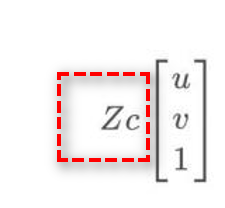

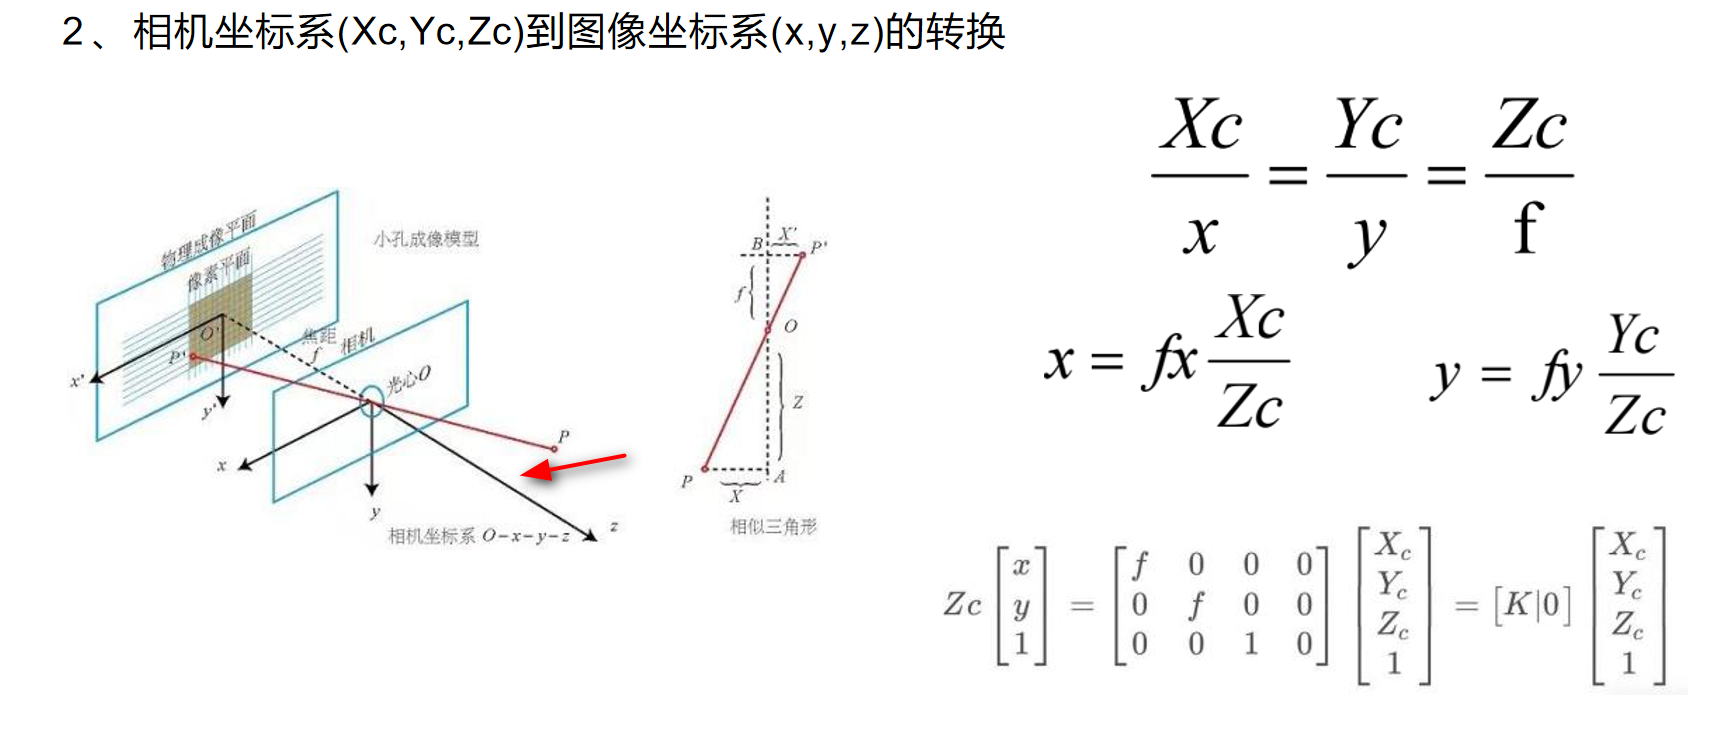



In [7]:
import numpy as np
 
# 内参矩阵
K = mtx
 
# 位姿矩阵（简化为只有平移的情况）
pose=T1
 
# 外参矩阵（位姿矩阵的逆）
extrinsic = np.linalg.inv(pose)
 
# 3D点（世界坐标系）
point_3d = np.array([0, -0.28, 0, 1])
 
# 将点从世界坐标系转换到相机坐标系
point_camera = extrinsic @ point_3d
 
# 投影到图像平面
point_2d = K @ point_camera[:3]
depth=point_2d[2]
point_2d /= depth  # 归一化
 
print("2D 图像点:")
print(point_2d[:2])

2D 图像点:
[404.49355513 236.9305    ]


`extrinsic` 外参矩阵（位姿矩阵的逆）：

### 各部分解释：

1. **`pose`**:
   - 这是相机的位姿矩阵（pose matrix）
   - 通常是一个4×4的齐次变换矩阵
   - 描述了相机坐标系相对于世界坐标系的变换关系
   - 包含了相机的位置（平移）和姿态（旋转）信息

2. **`np.linalg.inv()`**:
   - 这是NumPy库中的矩阵求逆函数
   - 用于计算矩阵的逆矩阵

3. **`extrinsic`**:
   - 结果是外参矩阵（extrinsic matrix）
   - 也称为视图矩阵（view matrix）

### 矩阵格式：

`extrinsic` 矩阵是一个4×4的齐次变换矩阵，格式为：
```
[ R11  R12  R13  tx ]
[ R21  R22  R23  ty ]
[ R31  R32  R33  tz ]
[  0    0    0   1  ]
```
其中R表示旋转部分，t表示平移部分。

In [45]:
extrinsic

array([[-8.36449319e-17, -8.66025404e-01,  5.00000000e-01,
        -2.47855081e-01],
       [-1.00000000e+00,  3.06161700e-17, -1.14261102e-16,
         5.14020469e-18],
       [ 8.36449319e-17, -5.00000000e-01, -8.66025404e-01,
        -3.07024072e-02],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00]])

深度

In [8]:
depth

0.11589675298686498

减去光心坐标

In [9]:
point_2d[0]-356.41270451

48.08085061616566

In [10]:
point_2d[1]-236.9305 

-5.684341886080802e-14

**移动相机**

In [11]:
T2=np.array(DFbot1.fkine([np.pi/2,-np.pi/6,0,np.pi,0,0]))
T2[1,-1]=-0.23

In [25]:
# 内参矩阵
K = mtx
 
# 位姿矩阵（简化为只有平移的情况）
pose=T2
 
# 外参矩阵（位姿矩阵的逆）
extrinsic = np.linalg.inv(pose)
 
# 3D点（世界坐标系）
point_3d = np.array([0, -0.28, 0, 1])
 
# 将点从世界坐标系转换到相机坐标系
point_camera = extrinsic @ point_3d
 
# 投影到图像平面
point_2d = K @ point_camera[:3]
depth=point_2d[2]
point_2d /= depth  # 归一化
 
print("2D 图像点:")
print(point_2d[:2])

2D 图像点:
[311.26676701 236.9305    ]


### 各部分解释：
point_camera[:3]:

这是从 point_camera 数组中取出前3个元素
point_camera 是一个齐次坐标表示的3D点，形式为 [x, y, z, 1]
[:3] 表示取前3个元素，即 [x, y, z]，去掉齐次坐标中的1

K: 相机内参矩阵（Intrinsic Matrix）

In [26]:
K@point_camera[:3]

array([34.02070835, 25.89593331,  0.10929759])

## 逆过程

### 已知像素坐标和机械臂位姿，求解世界坐标。

物体与相机的深度信息

In [27]:
depth = 0.1142975927850167
depth

0.1142975927850167

物体中心在相机中的像素坐标

In [28]:
xaxis=404.49355513+400
yaxis=236.9305 
xaxis,yaxis

(804.49355513, 236.9305)

计算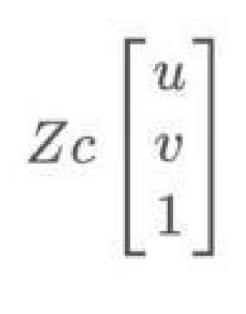

In [29]:
point_2d=depth*np.array([xaxis,yaxis,1])
point_2d

array([91.95167676, 27.08058581,  0.11429759])

求相机坐标

将二维图像点转换为三维相机坐标系中的射线。

### 各部分解释：

1. **`point_2d`**: 这是图像平面上的二维点坐标，通常形式为 `[u, v, 1]`（齐次坐标）

2. **`K`**: 这是相机的内参矩阵（Intrinsic Matrix），形式通常为：
   ```
   K = [fx  0  cx]
       [0  fy  cy]
       [0   0   1]
   ```
   其中 fx, fy 是焦距参数，cx, cy 是图像中心点坐标

3. **`np.linalg.inv(K)`**: 计算相机内参矩阵的逆矩阵

4. **`@`**: 这是矩阵乘法运算符

5. **`e2h()`**: 这是 `spatialmath` 库中的函数，将欧几里得坐标（Euclidean）转换为齐次坐标（Homogeneous）

### 功能说明：

这段代码的作用是**将图像坐标系中的二维点反投影到相机坐标系中**：

1. 首先通过相机内参矩阵的逆矩阵，将图像点从像素坐标转换到归一化图像坐标平面
2. 然后转换为齐次坐标表示

### 几何意义：

这个操作实际上是**反投影过程**的第一步：
- 给定图像上的一个点 `point_2d`
- 计算从相机光心出发，通过该图像点的三维射线方向
- 结果 `point_camera` 表示该射线在相机坐标系中的方向向量

在机器人视觉抓取任务中，这一步是将图像中检测到的目标点转换为机器人可操作的三维空间信息的关键步骤。



### 功能说明：

这段代码的作用是将图像坐标系中的二维点反投影到相机坐标系中：

首先通过相机内参矩阵的逆矩阵，将图像点从像素坐标转换到归一化图像坐标平面
然后转换为齐次坐标表示

### 几何意义：

这个操作实际上是反投影过程的第一步：

给定图像上的一个点 point_2d
计算从相机光心出发，通过该图像点的三维射线方向
结果 point_camera 表示该射线在相机坐标系中的方向向量

In [ ]:
point_camera=e2h(np.linalg.inv(K)@point_2d)
point_camera

array([[ 5.57152507e-02],
       [-4.39480381e-18],
       [ 1.14297593e-01],
       [ 1.00000000e+00]])

求世界坐标

将相机坐标系中的3D点转换到世界坐标系中。

### 各部分解释：

1. **`extrinsic`**: 
   - 外参矩阵，描述相机坐标系相对于世界坐标系的变换关系
   - 通常包含旋转和平移信息

2. **`np.linalg.inv(extrinsic)`**:
   - 计算外参矩阵的逆矩阵
   - 逆变换用于从相机坐标系转换到世界坐标系

3. **`point_camera`**:
   - 相机坐标系中的3D点坐标
   - 这是之前通过视觉测量得到的点位置

4. **`@` 运算符**:
   - 矩阵乘法运算符
   - 将逆变换矩阵应用到相机坐标点上

5. **`np.array()`**:
   - 确保结果为NumPy数组格式

### 功能说明：

这是**坐标系变换**操作：
- 输入：相机坐标系中的3D点 `point_camera`
- 变换：使用外参矩阵的逆变换
- 输出：对应的世界坐标系中的3D点 `new_point_3d`

### 数学原理：

```
P_world = T_camera_to_world^(-1) × P_camera
```

其中：
- `T_camera_to_world` 是从世界坐标系到相机坐标系的变换
- `T_camera_to_world^(-1)` 是从相机坐标系到世界坐标系的变换



In [31]:
new_point_3d=np.array(np.linalg.inv(extrinsic)@point_camera)
new_point_3d

array([[-3.72859607e-18],
       [-3.35399619e-01],
       [ 2.62114822e-02],
       [ 1.00000000e+00]])

### 已知世界坐标，进行机械臂抓取

In [33]:
T1=DFbot1.fkine([np.pi/2,-np.pi/6,0,np.pi,0,0])
T1

   0        -1         0         0         
  -0.866     0        -0.5      -0.2168    
   0.5       0        -0.866     0.09734   
   0         0         0         1         


In [35]:
T21=DFbot2.fkine([np.pi/2,-np.pi/6,0,np.pi,0])
T21

   0        -1         0         0         
  -0.866     0        -0.5      -0.1985    
   0.5       0        -0.866     0.02904   
   0         0         0         1         


创建一个新的变换矩阵 `T2`，将原来 `T21` 矩阵的平移部分替换为新的平移向量。

### 各部分解释：

1. **`T2 = np.array(T21)`**:
   - 创建 `T21` 的一个副本并赋值给 `T2`
   - `T21` 是一个4×4的齐次变换矩阵，包含了旋转和平移信息
   - 使用 `np.array()` 确保创建的是独立的数组副本，而不是引用

2. **`T2[:, -1] = new_point_3d.flatten()`**:
   - `T2[:, -1]` 选择矩阵 `T2` 的最后一列（所有行的最后一个元素）
   - 在4×4齐次变换矩阵中，最后一列表示平移向量 [x, y, z, 1]
   - `new_point_3d.flatten()` 将新的3D点坐标展平为一维数组
   - 这行代码将原矩阵的平移部分替换为新的平移向量

3. **`T2`**:
   - 返回修改后的变换矩阵

### 功能说明：

这段代码实现了**替换变换矩阵的平移部分**：

1. 原始的 `T21` 矩阵形式为：
   ```
   [r11  r12  r13  tx]
   [r21  r22  r23  ty]  
   [r31  r32  r33  tz]
   [0    0    0    1 ]
   ```
   其中 `r` 是旋转部分，`t` 是平移部分

2. 通过 `T2[:, -1] = new_point_3d.flatten()` 操作后：
   - 旋转部分保持不变
   - 平移部分 `[tx, ty, tz, 1]` 被替换为 `new_point_3d` 的值

### 应用场景：

在机器人视觉抓取任务中，这种操作通常用于：
- **目标定位**：将检测到的3D目标点作为新的相机位置
- **坐标变换**：更新相机或机械臂的位姿矩阵
- **路径规划**：设置机械臂末端执行器的目标位置

这相当于告诉机器人："保持原来的姿态（旋转），但移动到新的位置（平移）"。



In [40]:
T2=np.array(T21)
T2[:,-1]=new_point_3d.flatten()
T2

array([[-8.36449319e-17, -1.00000000e+00,  8.36449319e-17,
        -3.72859607e-18],
       [-8.66025404e-01,  3.06161700e-17, -5.00000000e-01,
        -3.35399619e-01],
       [ 5.00000000e-01, -1.14261102e-16, -8.66025404e-01,
         2.62114822e-02],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00]])

使用机械臂的逆运动学求解器来计算达到指定末端位姿所需的关节角度。

## 代码功能解析

```python
sol = DFbot2.ikine_LM(T2,q0=[np.pi/2,-np.pi/6,0,np.pi,0],ilimit=500, slimit=500,joint_limits=True,tol=0.02)
```

### 各参数解释：

1. **`DFbot2.ikine_LM`**: 
   - 调用 `DFbot2` 机械臂对象的逆运动学求解方法
   - `LM` 表示使用 Levenberg-Marquardt 算法进行数值求解

2. **`T2`**: 
   - 目标末端位姿变换矩阵
   - 这是前面代码中计算得到的目标位置和姿态

3. **`q0=[np.pi/2,-np.pi/6,0,np.pi,0]`**:
   - 初始关节角度猜测值
   - 提供求解器一个起始点，帮助收敛到合理解
   - 包含5个关节角度：[π/2, -π/6, 0, π, 0]

4. **`ilimit=500`**:
   - 迭代次数限制为500次
   - 防止求解器无限循环

5. **`slimit=500`**:
   - 搜索次数限制为500次
   - 控制求解器的搜索范围

6. **`joint_limits=True`**:
   - 启用关节限位检查
   - 确保求解结果在机械臂物理限制范围内

7. **`tol=0.02`**:
   - 求解精度容差为0.02
   - 控制解的精度要求

### 功能说明：

这段代码的目的是**逆运动学求解**：

1. **输入**：期望的末端执行器位姿 `T2`
2. **输出**：能够达到该位姿的各关节角度值
3. **算法**：使用 Levenberg-Marquardt 数值优化算法
4. **约束**：考虑关节角度限制，确保解的可行性

### 应用场景：

在机器人视觉抓取系统中，这一步是关键的路径规划环节：
- 根据视觉系统计算出的目标物体位置（`T2`）
- 计算机械臂需要运动到的关节角度
- 确保机械臂能够准确抓取目标物体

### 返回值：

`sol` 对象通常包含：
- `q`: 求解得到的关节角度数组
- `success`: 求解是否成功的标志
- `iterations`: 实际使用的迭代次数
- `error`: 最终的求解误差

这是机器人从"看到目标"到"移动抓取"的关键转换步骤。

In [42]:
sol = DFbot2.ikine_LM(T2,q0=[np.pi/2,-np.pi/6,0,np.pi,0],ilimit=500, slimit=500,joint_limits=True,tol=0.02)
sol

IKSolution(q=array([ 1.57079633, -0.26972789, -0.00343891,  2.88084396,  0.        ]), success=True, iterations=1, searches=1, residual=0.009374689127376561, reason='Success')

In [43]:
sol.q - [np.pi/2,-np.pi/6,0,np.pi,0]

array([ 0.        ,  0.25387089, -0.00343891, -0.2607487 ,  0.        ])

是生成机械臂关节空间的轨迹。

### 各部分解释：

1. **`jtraj`**:
   - 这是Robotics Toolbox中的关节空间轨迹生成函数
   - 用于在两个关节角度配置之间生成平滑的轨迹

2. **起始关节角度**:`[np.pi/2,-np.pi/6,0,np.pi,0]`
   - 这是机械臂的初始关节角度配置
   - 对应DFbot2机械臂的5个关节角度

3. **目标关节角度**:`sol.q`
   - 这是通过逆运动学求解得到的目标关节角度
   - `sol`是`DFbot2.ikine_LM()`函数的求解结果
   - `.q`属性包含求解出的关节角度值

4. **轨迹点数**:`10`
   - 生成从起始位置到目标位置的10个中间点
   - 包括起始点和终点在内

### 功能说明：

这行代码生成一个**关节空间的线性轨迹**：
- 从当前关节角度配置移动到逆运动学求解的目标角度
- 生成10个轨迹点，每点包含所有5个关节的角度值
- 轨迹存储在`qt`变量中，可以用于后续的机械臂运动控制

### 应用场景：

在机器人抓取任务中，这个轨迹可以用于：
1. 控制机械臂从当前位置平滑移动到目标位置
2. 避免关节角度突变造成的机械冲击
3. 实现精确的位置控制

### 注意事项：

- 确保`sol.q`是有效的逆运动学解（检查`sol.success`是否为True）
- 轨迹点数可以根据需要调整，点数越多运动越平滑但计算量越大

In [44]:
qt=jtraj([np.pi/2,-np.pi/6,0,np.pi,0],sol.q,10)
DFbot2.plot(qt.q,backend='pyplot',movie='panda1.gif')

PyPlot3D backend, t = 0.49999999999999994, scene:
  robot: Text(0.0, 0.0, 'DFbot')